In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!apt-get install -y libopenexr-dev
!pip install openexr torch torchvision numpy
!pip install pyexr
!pip install torch torchvision pyexr numpy

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libopenexr-dev is already the newest version (2.5.7-1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


In [33]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import OpenEXR
import Imath
from tqdm import tqdm

EPSILON  = 0.00316

# ── EXR loading ──────────────────────────────────────────────

def read_exr_channels(path, channels):
    exr   = OpenEXR.InputFile(path)
    dw    = exr.header()['dataWindow']
    W     = dw.max.x - dw.min.x + 1
    H     = dw.max.y - dw.min.y + 1
    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)
    result = {}
    for ch in channels:
        raw        = np.frombuffer(exr.channel(ch, FLOAT), dtype=np.float32)
        result[ch] = raw.reshape(H, W)
    return result, H, W

def load_noisy_buffers(path):
    needed = [
        'diffuse.R',  'diffuse.G',  'diffuse.B',
        'diffuseA.R', 'diffuseA.G', 'diffuseA.B',
        'specular.R', 'specular.G', 'specular.B',
        'specularA.R','specularA.G','specularA.B',
        'albedo.R',   'albedo.G',   'albedo.B',
        'normal.R',   'normal.G',   'normal.B',
        'normalA.R',  'normalA.G',  'normalA.B',
        'depth.Z',    'depthA.Z',
    ]
    ch, H, W = read_exr_channels(path, needed)
    def rgb(prefix):
        return np.stack([ch[f'{prefix}.R'],
                         ch[f'{prefix}.G'],
                         ch[f'{prefix}.B']], axis=-1)
    diffuse1  = rgb('diffuse');  diffuse2  = rgb('diffuseA')
    specular1 = rgb('specular'); specular2 = rgb('specularA')
    normal1   = rgb('normal');   normal2   = rgb('normalA')
    depth1    = ch['depth.Z'][..., np.newaxis]
    depth2    = ch['depthA.Z'][..., np.newaxis]
    return {
        'diffuse'        : diffuse1,
        'specular'       : specular1,
        'albedo'         : rgb('albedo'),
        'normal'         : normal1,
        'depth'          : depth1,
        'sigma2_diffuse' : 0.5 * (diffuse1  - diffuse2)  ** 2,
        'sigma2_specular': 0.5 * (specular1 - specular2) ** 2,
        'sigma2_normal'  : 0.5 * (normal1   - normal2)   ** 2,
    }

def load_reference_buffers(path):
    needed = [
        'diffuse.R',  'diffuse.G',  'diffuse.B',
        'specular.R', 'specular.G', 'specular.B',
        'albedo.R',   'albedo.G',   'albedo.B',
    ]
    ch, H, W = read_exr_channels(path, needed)
    def rgb(prefix):
        return np.stack([ch[f'{prefix}.R'],
                         ch[f'{prefix}.G'],
                         ch[f'{prefix}.B']], axis=-1)
    return {'diffuse': rgb('diffuse'),
            'specular': rgb('specular'),
            'albedo':  rgb('albedo')}

# ── Preprocessing ─────────────────────────────────────────────

def to_luminance(x):
    if x.shape[-1] == 3:
        return (0.2126*x[...,0:1] + 0.7152*x[...,1:2] + 0.0722*x[...,2:3])
    return x

def spatial_gradients(x):
    return np.gradient(x, axis=1), np.gradient(x, axis=0)

def preprocess_diffuse(b):
    depth          = to_luminance(b['depth'])
    sigma2_diffuse = to_luminance(b['sigma2_diffuse'])
    sigma2_normal  = to_luminance(b['sigma2_normal'])
    irradiance     = b['diffuse'] / (b['albedo'] + EPSILON)
    sigma2_irr     = sigma2_diffuse / (to_luminance(b['albedo']) + EPSILON) ** 2
    gx_irr,  gy_irr  = spatial_gradients(irradiance)
    gx_norm, gy_norm = spatial_gradients(b['normal'])
    gx_dep,  gy_dep  = spatial_gradients(depth)
    features = np.concatenate([
        irradiance, gx_irr, gy_irr,
        b['normal'], gx_norm, gy_norm,
        depth, gx_dep, gy_dep,
        sigma2_irr, sigma2_normal,
    ], axis=-1)                          # [H,W,23]
    return features, irradiance

def preprocess_specular(b):
    depth           = to_luminance(b['depth'])
    sigma2_specular = to_luminance(b['sigma2_specular'])
    sigma2_normal   = to_luminance(b['sigma2_normal'])
    spec_log        = np.log1p(b['specular'])
    sigma2_log      = sigma2_specular / (to_luminance(b['specular']) + 1.0) ** 2
    gx_spec, gy_spec = spatial_gradients(spec_log)
    gx_norm, gy_norm = spatial_gradients(b['normal'])
    gx_dep,  gy_dep  = spatial_gradients(depth)
    features = np.concatenate([
        spec_log, gx_spec, gy_spec,
        b['normal'], gx_norm, gy_norm,
        depth, gx_dep, gy_dep,
        sigma2_log, sigma2_normal,
    ], axis=-1)                          # [H,W,23]
    return features, spec_log

# ── Model ─────────────────────────────────────────────────────

class KPCN(nn.Module):
    def __init__(self, in_channels=23, kernel_size=21):
        super().__init__()
        self.kernel_size = kernel_size
        k = kernel_size
        layers  = [nn.Conv2d(in_channels, 100, 5, padding=2), nn.ReLU(inplace=True)]
        for _   in range(7):
            layers += [nn.Conv2d(100, 100, 5, padding=2), nn.ReLU(inplace=True)]
        layers  += [nn.Conv2d(100, k*k, 5, padding=2)]
        self.network = nn.Sequential(*layers)

    def forward(self, features, noisy_color):
        B, _, H, W = noisy_color.shape
        k   = self.kernel_size
        raw = self.network(features)
        w   = F.softmax(raw, dim=1)
        unf = F.unfold(noisy_color, kernel_size=k, padding=k//2)
        unf = unf.view(B, 3, k*k, H*W)
        w   = w.view(B, k*k, H*W).unsqueeze(1)
        return (unf * w).sum(dim=2).view(B, 3, H, W)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# ── Dataset ───────────────────────────────────────────────────

class KPCNDatasetCached(Dataset):
    def __init__(self, cache_paths, patch_size=65, patches_per_frame=40):
        self.cache_paths       = cache_paths
        self.patch_size        = patch_size
        self.patches_per_frame = patches_per_frame
        # Load all npz files into RAM once — much faster than reading per batch
        print(f"Loading {len(cache_paths)} npz files into RAM...")
        self.data = [np.load(p) for p in cache_paths]
        print(f"Dataset ready: {len(cache_paths)} frames, "
              f"{len(cache_paths)*patches_per_frame} patches/epoch")

    def __len__(self):
        return len(self.cache_paths) * self.patches_per_frame

    def __getitem__(self, idx):
        data = self.data[idx % len(self.data)]
        H, W = data['diff_feat'].shape[:2]
        ps   = self.patch_size
        top  = np.random.randint(0, H - ps)
        left = np.random.randint(0, W - ps)
        def crop(key):
            return torch.from_numpy(
                data[key][top:top+ps, left:left+ps]
            ).permute(2, 0, 1)
        return {k: crop(k) for k in
                ['diff_feat','diff_irr','diff_target',
                 'albedo','spec_feat','spec_log','spec_target']}

# ── Caching helpers ───────────────────────────────────────────

def find_pairs(scene_dirs):
    pairs = []
    for scene_dir in scene_dirs:
        for f in sorted(os.listdir(scene_dir)):
            if '00128spp.exr' in f:
                base  = f.replace('-00128spp.exr', '')
                ref   = os.path.join(scene_dir, base + '-08192spp.exr')
                noisy = os.path.join(scene_dir, f)
                if os.path.exists(ref):
                    pairs.append((noisy, ref))
    print(f"Found {len(pairs)} pairs")
    return pairs

def cache_pair(noisy_path, ref_path, cache_dir):
    scene      = os.path.basename(os.path.dirname(noisy_path))
    basename   = os.path.basename(noisy_path).replace('-00128spp.exr', '')
    cache_path = os.path.join(cache_dir, f'{scene}_{basename}.npz')
    if os.path.exists(cache_path):
        return cache_path
    nb = load_noisy_buffers(noisy_path)
    rb = load_reference_buffers(ref_path)
    df, di = preprocess_diffuse(nb)
    sf, sl = preprocess_specular(nb)
    np.savez_compressed(cache_path,
        diff_feat   = df.astype(np.float32),
        diff_irr    = di.astype(np.float32),
        diff_target = (rb['diffuse'] / (rb['albedo'] + EPSILON)).astype(np.float32),
        albedo      = nb['albedo'].astype(np.float32),
        spec_feat   = sf.astype(np.float32),
        spec_log    = sl.astype(np.float32),
        spec_target = np.log1p(rb['specular']).astype(np.float32),
    )
    return cache_path

def cache_all(pairs, cache_dir):
    os.makedirs(cache_dir, exist_ok=True)
    paths = []
    for i, (n, r) in enumerate(pairs):
        paths.append(cache_pair(n, r, cache_dir))
        if (i+1) % 10 == 0:
            print(f"  {i+1}/{len(pairs)} done")
    print(f"Done — {len(paths)} files")
    return paths

print("All definitions loaded.")

All definitions loaded.


In [30]:
CACHE_DIR = '/content/drive/MyDrive/469_cache/'

all_files = sorted(f for f in os.listdir(CACHE_DIR) if f.endswith('.npz'))

train_cache_paths = [os.path.join(CACHE_DIR, f) for f in all_files
                     if f.startswith('room')]
test_cache_paths  = [os.path.join(CACHE_DIR, f) for f in all_files
                     if f.startswith('car')]

print(f"Train files: {len(train_cache_paths)}")
print(f"Test files : {len(test_cache_paths)}")


# Old Caching Implementation
# train_pairs = find_pairs([
#     '/content/drive/MyDrive/CMPT469/469_data/room2',
#     '/content/drive/MyDrive/CMPT469/469_data/room3',
# ])
# test_pairs = find_pairs([
#     '/content/drive/MyDrive/CMPT469/469_data/car2',
# ])

# existing = [f for f in os.listdir(CACHE_DIR) if f.endswith('.npz')] \
#            if os.path.exists(CACHE_DIR) else []

# if len(existing) >= len(train_pairs) + len(test_pairs):
#     print(f"Cache complete ({len(existing)} files) — skipping.")
#     all_files         = sorted(existing)
#     train_cache_paths = [os.path.join(CACHE_DIR, f) for f in all_files
#                          if f.startswith('room')]
#     test_cache_paths  = [os.path.join(CACHE_DIR, f) for f in all_files
#                          if f.startswith('car')]
# else:
#     print("Building cache...")
#     train_cache_paths = cache_all(train_pairs, CACHE_DIR)
#     test_cache_paths  = cache_all(test_pairs,  CACHE_DIR)

# print(f"Train: {len(train_cache_paths)}  Test: {len(test_cache_paths)}")

Train files: 388
Test files : 180


=== Training frame (room) ===


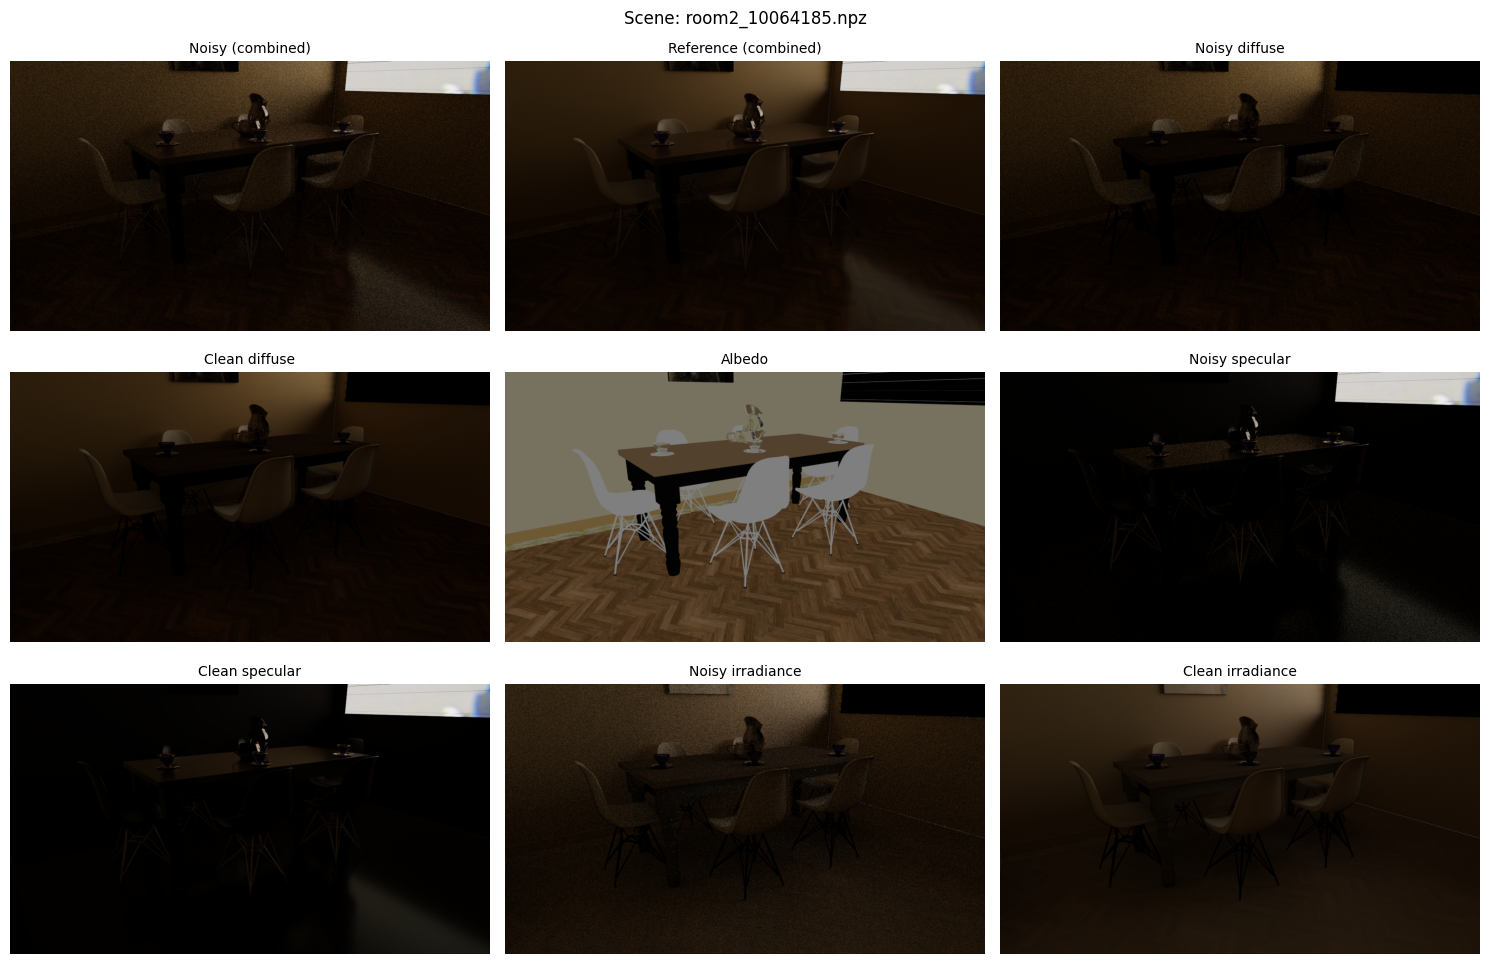

=== Test frame (car) ===


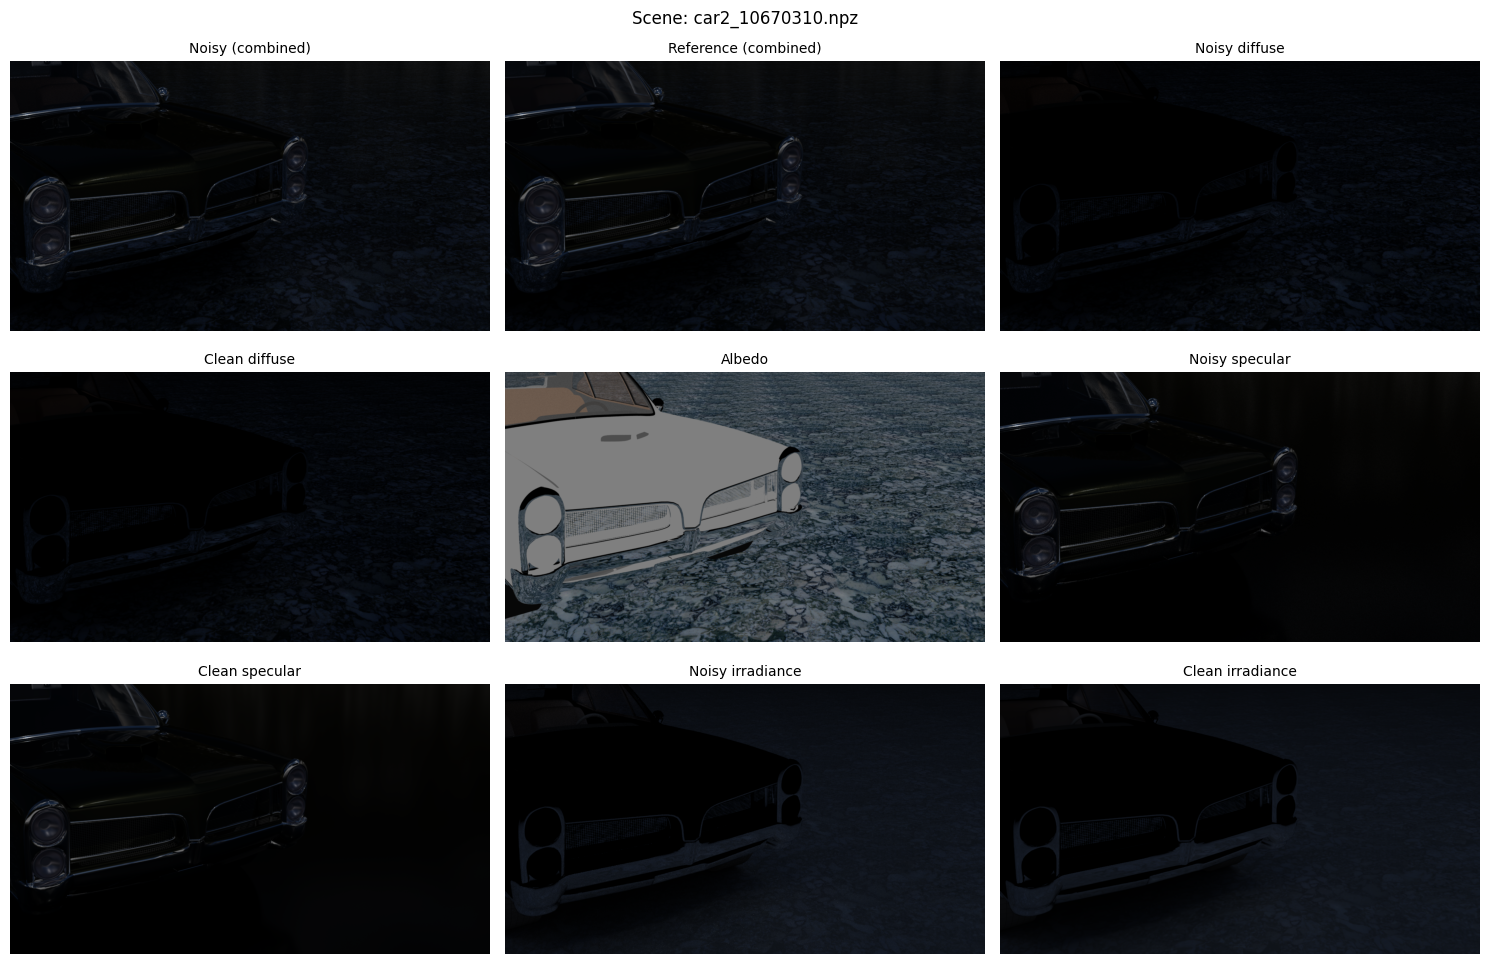

In [36]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_pair(cache_path, save_path=None):
    """Show all components of a noisy/reference pair from a cached npz file."""
    data = np.load(cache_path)

    # Extract full-resolution arrays (not patches)
    diff_irr    = data['diff_irr']      # [H,W,3] noisy irradiance
    diff_target = data['diff_target']   # [H,W,3] clean irradiance
    albedo      = data['albedo']        # [H,W,3]
    spec_log    = data['spec_log']      # [H,W,3] noisy log-specular
    spec_target = data['spec_target']  # [H,W,3] clean log-specular

    # Reconstruct color images from components
    noisy_diffuse  = (albedo + EPSILON) * diff_irr
    clean_diffuse  = (albedo + EPSILON) * diff_target
    noisy_specular = np.expm1(spec_log)     # invert log transform
    clean_specular = np.expm1(spec_target)
    noisy_combined = noisy_diffuse + noisy_specular
    clean_combined = clean_diffuse + clean_specular

    def tone_map(x):
        """Simple Reinhard tone mapping for display — HDR → [0,1]."""
        x = np.clip(x, 0, None)
        return x / (1 + x)

    panels = [
        (tone_map(noisy_combined),  'Noisy (combined)'),
        (tone_map(clean_combined),  'Reference (combined)'),
        (tone_map(noisy_diffuse),   'Noisy diffuse'),
        (tone_map(clean_diffuse),   'Clean diffuse'),
        (tone_map(albedo),          'Albedo'),
        (tone_map(noisy_specular),  'Noisy specular'),
        (tone_map(clean_specular),  'Clean specular'),
        # Irradiance (lighting only, no texture)
        (tone_map(diff_irr),        'Noisy irradiance'),
        (tone_map(diff_target),     'Clean irradiance'),
    ]

    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()

    for ax, (img, title) in zip(axes, panels):
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    plt.suptitle(f"Scene: {os.path.basename(cache_path)}", fontsize=12)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")

    plt.show()


# Visualize one training frame and one test frame
print("=== Training frame (room) ===")
visualize_pair(train_cache_paths[0])

print("=== Test frame (car) ===")
visualize_pair(test_cache_paths[0])

In [31]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

train_dataset = KPCNDatasetCached(train_cache_paths, patch_size=65, patches_per_frame=40)
test_dataset  = KPCNDatasetCached(test_cache_paths,  patch_size=65, patches_per_frame=1)

train_loader  = DataLoader(train_dataset, batch_size=4, shuffle=True,
                           num_workers=0, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=1, shuffle=False,
                           num_workers=0, pin_memory=True)

diffuse_net  = KPCN(in_channels=23, kernel_size=21).to(device)
specular_net = KPCN(in_channels=23, kernel_size=21).to(device)

print(f"Diffuse net  params: {count_params(diffuse_net):,}")
print(f"Specular net params: {count_params(specular_net):,}")

# Verify one batch
batch = next(iter(train_loader))
for k, v in batch.items():
    print(f"  {k:15s}: {tuple(v.shape)}")

Device: cpu
Loading 388 npz files into RAM...
Dataset ready: 388 frames, 15520 patches/epoch
Loading 180 npz files into RAM...
Dataset ready: 180 frames, 180 patches/epoch
Diffuse net  params: 2,911,241
Specular net params: 2,911,241


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  diff_feat      : (4, 23, 65, 65)
  diff_irr       : (4, 3, 65, 65)
  diff_target    : (4, 3, 65, 65)
  albedo         : (4, 3, 65, 65)
  spec_feat      : (4, 23, 65, 65)
  spec_log       : (4, 3, 65, 65)
  spec_target    : (4, 3, 65, 65)


In [34]:
optimizer_diff = torch.optim.Adam(diffuse_net.parameters(),  lr=1e-5)
optimizer_spec = torch.optim.Adam(specular_net.parameters(), lr=1e-5)
criterion      = nn.L1Loss()

def reconstruct(denoised_irr, albedo, denoised_spec_log):
    return (albedo + EPSILON) * denoised_irr + torch.expm1(denoised_spec_log)

def compute_psnr(output, target):
    mse = torch.mean((output - target) ** 2)
    if mse == 0:
        return torch.tensor(float('inf'))
    return -10 * torch.log10(mse)

def train_epoch(loader, diffuse_net, specular_net,
                opt_d, opt_s, criterion, device):
    diffuse_net.train()
    specular_net.train()
    total_loss_d = total_loss_s = total_psnr = 0
    n_batches = 0

    pbar = tqdm(loader, desc='Train', leave=False)
    for batch in pbar:
        diff_feat   = batch['diff_feat'].to(device)
        diff_irr    = batch['diff_irr'].to(device)
        diff_target = batch['diff_target'].to(device)
        albedo      = batch['albedo'].to(device)
        spec_feat   = batch['spec_feat'].to(device)
        spec_log    = batch['spec_log'].to(device)
        spec_target = batch['spec_target'].to(device)

        # Diffuse
        opt_d.zero_grad()
        denoised_irr = diffuse_net(diff_feat, diff_irr)
        loss_d       = criterion(denoised_irr, diff_target)
        loss_d.backward()
        opt_d.step()

        # Specular
        opt_s.zero_grad()
        denoised_spec = specular_net(spec_feat, spec_log)
        loss_s        = criterion(denoised_spec, spec_target)
        loss_s.backward()
        opt_s.step()

        with torch.no_grad():
            final = reconstruct(denoised_irr, albedo, denoised_spec)
            ref   = reconstruct(diff_target,  albedo, spec_target)
            total_psnr += compute_psnr(final, ref).item()

        total_loss_d += loss_d.item()
        total_loss_s += loss_s.item()
        n_batches    += 1
        pbar.set_postfix(diff=f'{loss_d.item():.4f}', spec=f'{loss_s.item():.4f}')

    return total_loss_d/n_batches, total_loss_s/n_batches, total_psnr/n_batches


def eval_epoch(loader, diffuse_net, specular_net, criterion, device):
    diffuse_net.eval()
    specular_net.eval()
    total_loss_d = total_loss_s = total_psnr = 0
    n_batches = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc='Eval', leave=False):
            diff_feat   = batch['diff_feat'].to(device)
            diff_irr    = batch['diff_irr'].to(device)
            diff_target = batch['diff_target'].to(device)
            albedo      = batch['albedo'].to(device)
            spec_feat   = batch['spec_feat'].to(device)
            spec_log    = batch['spec_log'].to(device)
            spec_target = batch['spec_target'].to(device)

            denoised_irr  = diffuse_net(diff_feat, diff_irr)
            denoised_spec = specular_net(spec_feat, spec_log)

            loss_d = criterion(denoised_irr,  diff_target)
            loss_s = criterion(denoised_spec, spec_target)
            final  = reconstruct(denoised_irr, albedo, denoised_spec)
            ref    = reconstruct(diff_target,  albedo, spec_target)

            total_loss_d += loss_d.item()
            total_loss_s += loss_s.item()
            total_psnr   += compute_psnr(final, ref).item()
            n_batches    += 1

    return total_loss_d/n_batches, total_loss_s/n_batches, total_psnr/n_batches


EPOCHS   = 20
SAVE_DIR = '/content/drive/MyDrive/469_checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

history = {
    'train_loss_d': [], 'train_loss_s': [], 'train_psnr': [],
    'test_loss_d' : [], 'test_loss_s' : [], 'test_psnr' : [],
}

for epoch in range(1, EPOCHS + 1):
    train_ld, train_ls, train_psnr = train_epoch(
        train_loader, diffuse_net, specular_net,
        optimizer_diff, optimizer_spec, criterion, device)

    test_ld, test_ls, test_psnr = eval_epoch(
        test_loader, diffuse_net, specular_net, criterion, device)

    history['train_loss_d'].append(train_ld)
    history['train_loss_s'].append(train_ls)
    history['train_psnr'].append(train_psnr)
    history['test_loss_d'].append(test_ld)
    history['test_loss_s'].append(test_ls)
    history['test_psnr'].append(test_psnr)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train — diff: {train_ld:.4f}  spec: {train_ls:.4f}  psnr: {train_psnr:.2f}dB | "
          f"Test  — diff: {test_ld:.4f}  spec: {test_ls:.4f}  psnr: {test_psnr:.2f}dB")

    if epoch % 5 == 0:
        torch.save({
            'epoch'              : epoch,
            'diffuse_state_dict' : diffuse_net.state_dict(),
            'specular_state_dict': specular_net.state_dict(),
            'optimizer_diff'     : optimizer_diff.state_dict(),
            'optimizer_spec'     : optimizer_spec.state_dict(),
            'history'            : history,
        }, os.path.join(SAVE_DIR, f'kpcn_epoch_{epoch:02d}.pt'))
        print(f"  Checkpoint saved.")

torch.save({
    'diffuse_state_dict' : diffuse_net.state_dict(),
    'specular_state_dict': specular_net.state_dict(),
    'history'            : history,
}, os.path.join(SAVE_DIR, 'kpcn_final.pt'))
print("Training complete. Final model saved.")

Train:   0%|          | 0/3880 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 